# STAT 486 — Deliverable 2: Exploratory Data Analysis
**Airline Delay Prediction & Anomaly Detection**

This notebook produces all summary statistics, correlation matrices, and visualizations referenced in `progress/02_eda.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# ── SET THIS PATH ──────────────────────────────────────────────────────────────
DATA_PATH = Path("/Users/erica/STAT486proj/Data/Airline_Delay_Cause.csv")
FIG_DIR   = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

---
## 1. Load & Inspect

In [2]:
raw = pd.read_csv(DATA_PATH)

print(f"Shape (raw):  {raw.shape}")
print(f"Columns:      {list(raw.columns)}")
print(f"Year range:   {raw['year'].min()} – {raw['year'].max()}")
print(f"Carriers:     {raw['carrier'].nunique()}")
print(f"Airports:     {raw['airport'].nunique()}")
print()
print("Missing values per column:")
miss = raw.isnull().sum()
print(miss[miss > 0] if miss.any() else "  None")

Shape (raw):  (171666, 21)
Columns:      ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
Year range:   2013 – 2023
Carriers:     21
Airports:     395

Missing values per column:
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [3]:
raw.head(3)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0


---
## 2. Clean & Engineer Features

In [4]:
df = raw.copy()

# Drop rows with no flights (division guard)
n_before = len(df)
df = df[df["arr_flights"] > 0].reset_index(drop=True)
print(f"Rows dropped (arr_flights == 0): {n_before - len(df):,}")
print(f"Rows remaining:                 {len(df):,}")

# Rate features
df["delay_rate"]      = df["arr_del15"]    / df["arr_flights"]
df["cancel_rate"]     = df["arr_cancelled"] / df["arr_flights"]
df["divert_rate"]     = df["arr_diverted"]  / df["arr_flights"]
df["mean_delay_mins"] = df["arr_delay"]     / df["arr_flights"].clip(lower=1)

# Cause-fraction features
cause_cols   = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]
total_cause  = df[cause_cols].sum(axis=1).clip(lower=1)
for col in cause_cols:
    df[f"pct_{col}"] = df[col] / total_cause

# Seasonal flags
df["is_summer"]       = df["month"].isin([6, 7, 8]).astype(int)
df["is_winter"]       = df["month"].isin([12, 1, 2]).astype(int)
df["is_holiday_month"]= df["month"].isin([11, 12]).astype(int)
df["month_sin"]       = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"]       = np.cos(2 * np.pi * df["month"] / 12)

# Encode categoricals
le_carrier = LabelEncoder()
le_airport = LabelEncoder()
df["carrier_code"] = le_carrier.fit_transform(df["carrier"])
df["airport_code"] = le_airport.fit_transform(df["airport"])

# Binary target: top-quartile delay rate = "high delay"
threshold = df["delay_rate"].quantile(0.75)
df["high_delay"] = (df["delay_rate"] >= threshold).astype(int)

print(f"\nHigh-delay threshold (75th pct): {threshold:.4f}")
print(f"Positive class rate:             {df['high_delay'].mean()*100:.1f}%")

Rows dropped (arr_flights == 0): 240
Rows remaining:                 171,426

High-delay threshold (75th pct): 0.2415
Positive class rate:             25.0%


---
## 3. Summary Statistics
### 3a. Numeric variables

In [5]:
num_cols = [
    "arr_flights", "delay_rate", "cancel_rate", "divert_rate",
    "mean_delay_mins", "pct_carrier_ct", "pct_weather_ct",
    "pct_nas_ct", "pct_security_ct", "pct_late_aircraft_ct"
]

stats = df[num_cols].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
stats.columns = ["N", "Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]
stats = stats.round(4)
print(stats.to_string())
stats

                             N      Mean       Std  Min       Q1    Median        Q3      Max
arr_flights           171426.0  362.5285  992.8947  1.0  50.0000  100.0000  250.0000  21977.0
delay_rate            171223.0    0.1834    0.1103  0.0   0.1099    0.1707    0.2415      1.0
cancel_rate           171426.0    0.0248    0.0680  0.0   0.0000    0.0049    0.0245      1.0
divert_rate           171426.0    0.0028    0.0124  0.0   0.0000    0.0000    0.0010      1.0
mean_delay_mins       171426.0   11.4639   10.0466  0.0   5.3333    9.5568   15.1893    712.0
pct_carrier_ct        171426.0    0.3706    0.2185  0.0   0.2392    0.3488    0.4819      1.0
pct_weather_ct        171426.0    0.0435    0.0841  0.0   0.0000    0.0104    0.0531      1.0
pct_nas_ct            171426.0    0.2534    0.1975  0.0   0.1083    0.2317    0.3609      1.0
pct_security_ct       171426.0    0.0025    0.0186  0.0   0.0000    0.0000    0.0000      1.0
pct_late_aircraft_ct  171426.0    0.2904    0.1916  0.0   0.

,N,Mean,Std,Min,Q1,Median,Q3,Max
arr_flights,171426.0,362.5285,992.8947,1.0,50.0000,100.0000,250.0000,21977.0
delay_rate,171223.0,0.1834,0.1103,0.0,0.1099,0.1707,0.2415,1.0
cancel_rate,171426.0,0.0248,0.0680,0.0,0.0000,0.0049,0.0245,1.0
divert_rate,171426.0,0.0028,0.0124,0.0,0.0000,0.0000,0.0010,1.0
mean_delay_mins,171426.0,11.4639,10.0466,0.0,5.3333,9.5568,15.1893,712.0
pct_carrier_ct,171426.0,0.3706,0.2185,0.0,0.2392,0.3488,0.4819,1.0
pct_weather_ct,171426.0,0.0435,0.0841,0.0,0.0000,0.0104,0.0531,1.0
pct_nas_ct,171426.0,0.2534,0.1975,0.0,0.1083,0.2317,0.3609,1.0
pct_security_ct,171426.0,0.0025,0.0186,0.0,0.0000,0.0000,0.0000,1.0
pct_late_aircraft_ct,171426.0,0.2904,0.1916,0.0,0.1582,0.2943,0.4133,1.0


### 3b. Categorical variables

In [6]:
for col in ["carrier_name", "airport", "year", "month"]:
    print(f"\n── {col} ──")
    vc = df[col].value_counts()
    print(f"  Unique:  {vc.shape[0]}")
    print(f"  Top 5:\n{vc.head(5).to_string()}")


── carrier_name ──
  Unique:  23
  Top 5:
carrier_name
SkyWest Airlines Inc.     25538
Delta Air Lines Inc.      16678
Envoy Air                 11870
American Airlines Inc.    11814
United Air Lines Inc.     11248

── airport ──
  Unique:  391
  Top 5:
airport
DTW    1535
AUS    1529
RDU    1515
MSY    1514
ATL    1510

── year ──
  Unique:  11
  Top 5:
year
2019    20932
2022    20338
2018    20196
2021    19932
2020    18769

── month ──
  Unique:  12
  Top 5:
month
8    15668
1    14376
3    14340
6    14304
4    14199


### 3c. Class balance

In [7]:
balance = df["high_delay"].value_counts().rename({0: "low_delay", 1: "high_delay"})
balance_pct = (balance / len(df) * 100).round(1)
pd.DataFrame({"Count": balance, "Pct": balance_pct})

,Count,Pct
high_delay,,
low_delay,128620,75.0
high_delay,42806,25.0


### 3d. Correlation matrix

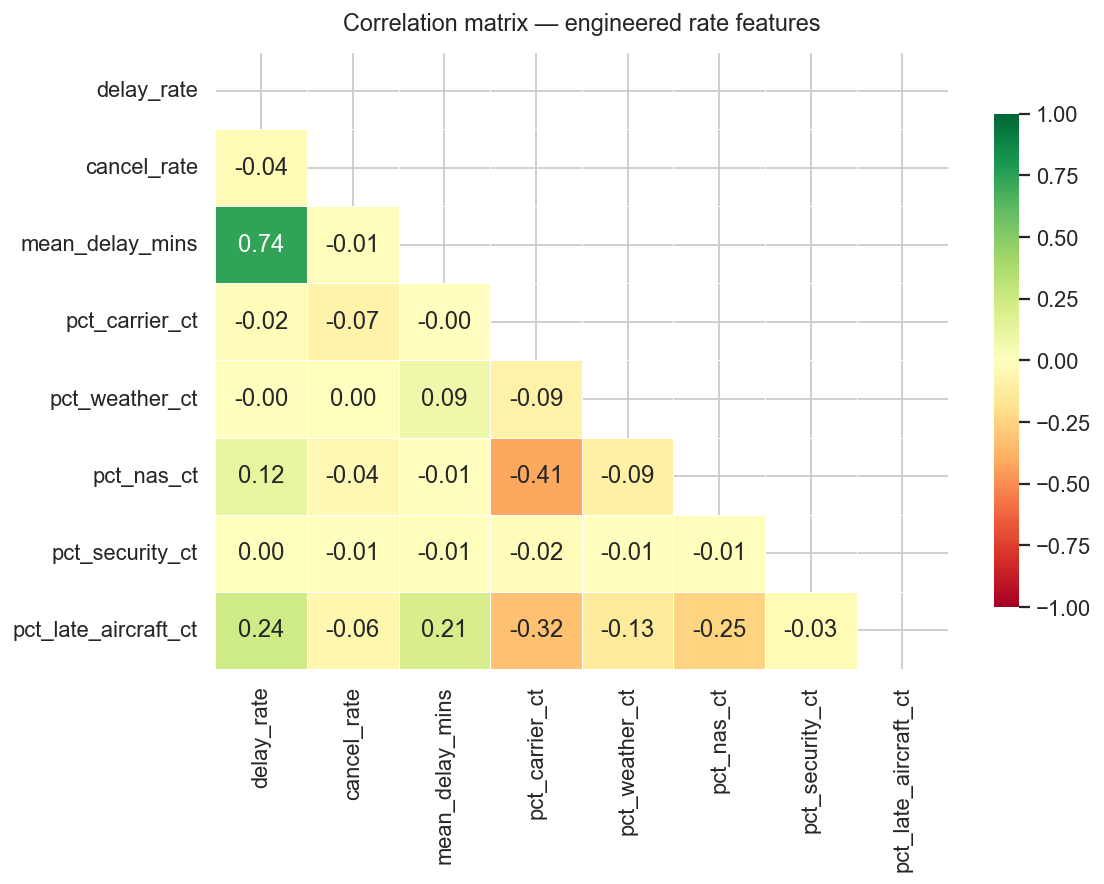

Saved: figures/corr_matrix.png


In [8]:
corr_cols = [
    "delay_rate", "cancel_rate", "mean_delay_mins",
    "pct_carrier_ct", "pct_weather_ct", "pct_nas_ct",
    "pct_security_ct", "pct_late_aircraft_ct"
]

corr = df[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle hidden
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation matrix — engineered rate features", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_matrix.png", dpi=150)
plt.show()
print("Saved: figures/corr_matrix.png")

**Key observations from the correlation matrix:**

- `pct_late_aircraft_ct` shows the strongest positive correlation with `delay_rate` among the cause fractions — cascade delays (one late inbound aircraft rippling across legs) are a dominant systemic driver.
- `pct_carrier_ct` and `pct_weather_ct` are negatively correlated by construction: the five cause fractions sum to 1, so any large weather share mechanically suppresses the carrier share.
- `cancel_rate` and `delay_rate` show a modest positive relationship — severe disruptions (weather, major operational failures) tend to spike both simultaneously.
- `arr_flights` (route/hub size) is intentionally excluded here; its low correlation with rate features confirms that volume alone is not a reliable predictor of delay propensity.

---
## 4. Visual Exploration

### Figure 1 — Delay Rate Distribution: High-Delay vs. Low-Delay Months

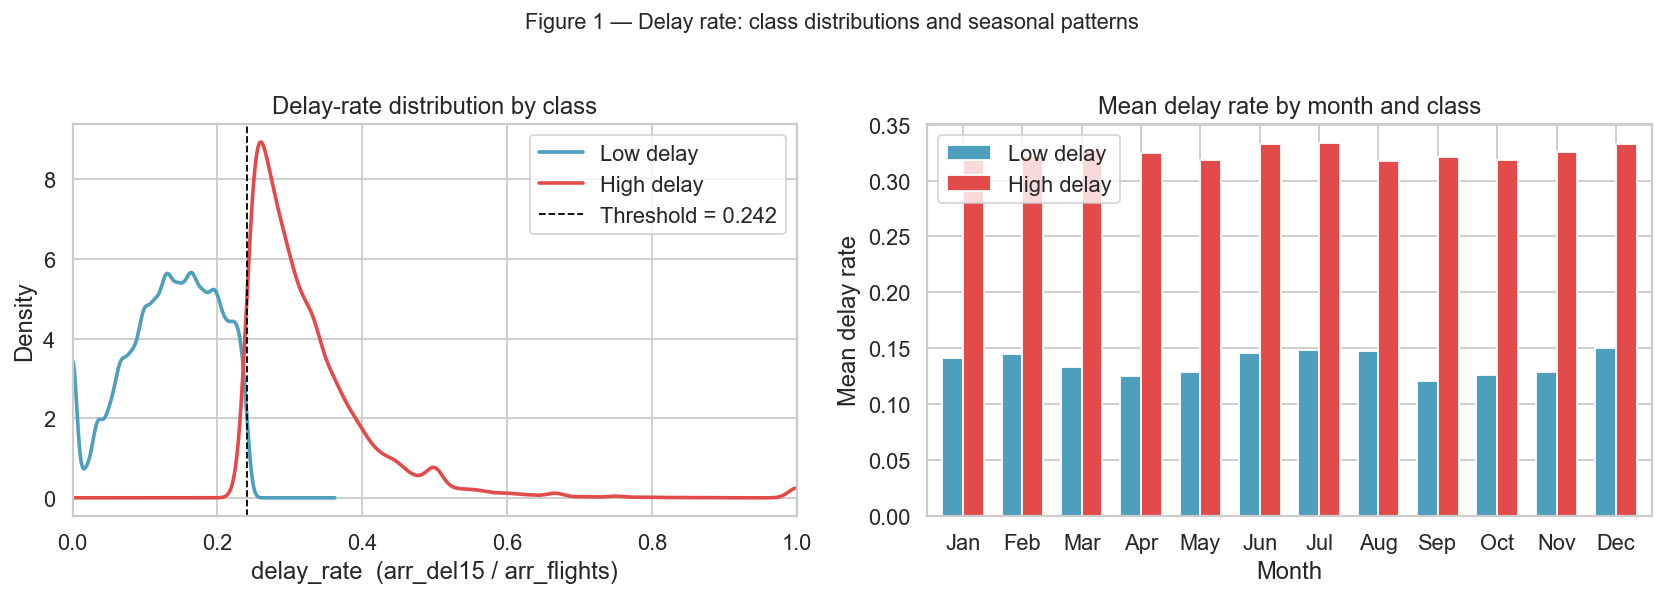

Saved: figures/fig1_delay_rate_by_class.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: KDE of delay_rate by class
for label, grp in df.groupby("high_delay"):
    name = "High delay" if label else "Low delay"
    color = "#E24B4A" if label else "#4E9EBD"
    grp["delay_rate"].plot.kde(ax=axes[0], label=name, color=color, linewidth=2)

axes[0].axvline(threshold, color="black", linestyle="--", linewidth=1,
                label=f"Threshold = {threshold:.3f}")
axes[0].set_xlabel("delay_rate  (arr_del15 / arr_flights)")
axes[0].set_ylabel("Density")
axes[0].set_title("Delay-rate distribution by class")
axes[0].legend()
axes[0].set_xlim(0, 1)

# Right: mean delay_rate by month, split by class
monthly = df.groupby(["month", "high_delay"])["delay_rate"].mean().unstack()
monthly.columns = ["Low delay", "High delay"]
monthly.plot(kind="bar", ax=axes[1],
             color=["#4E9EBD", "#E24B4A"], edgecolor="white", width=0.7)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].set_xticklabels(month_labels, rotation=0)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean delay rate")
axes[1].set_title("Mean delay rate by month and class")
axes[1].legend()

plt.suptitle("Figure 1 — Delay rate: class distributions and seasonal patterns",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_delay_rate_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig1_delay_rate_by_class.png")

**Figure 1 interpretation:**  
The left KDE shows the delay-rate distributions for the two classes separate cleanly around the 75th-percentile threshold, confirming the target is well-defined and not arbitrary. The right panel reveals clear seasonality: June–August (peak summer travel) and December–January (winter/holidays) show higher mean delay rates for both classes, validating the `is_summer` and `is_winter` flags as meaningful supervised features. This seasonal signal is directly relevant to the research question — a classifier that ignores month would be substantially weaker.

### Figure 2 — Delay Cause Composition: High-Delay vs. Low-Delay Months

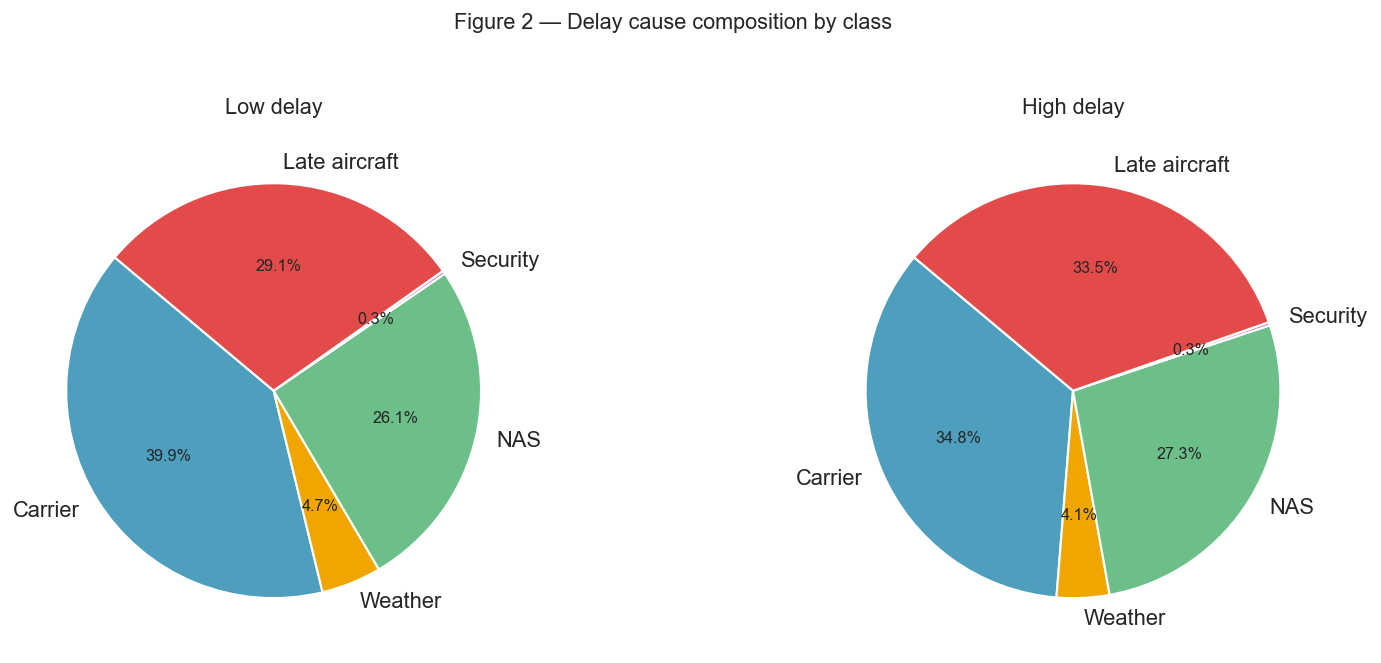

Saved: figures/fig2_cause_composition.png


In [10]:
cause_pct_cols = ["pct_carrier_ct", "pct_weather_ct", "pct_nas_ct",
                  "pct_security_ct", "pct_late_aircraft_ct"]
cause_labels   = ["Carrier", "Weather", "NAS", "Security", "Late aircraft"]
colors         = ["#4E9EBD", "#F0A500", "#6DBF8A", "#C97BBB", "#E24B4A"]

means = df.groupby("high_delay")[cause_pct_cols].mean()
means.index = ["Low delay", "High delay"]
means.columns = cause_labels

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (row_label, row) in zip(axes, means.iterrows()):
    wedges, texts, autotexts = ax.pie(
        row.values, labels=cause_labels, colors=colors,
        autopct="%1.1f%%", startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.2}
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.set_title(f"{row_label}", fontsize=12, pad=10)

plt.suptitle("Figure 2 — Delay cause composition by class", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_cause_composition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig2_cause_composition.png")

**Figure 2 interpretation:**  
Comparing the cause-composition pie charts between low- and high-delay months reveals which delay types are disproportionately present during high-delay periods. If late-aircraft and carrier fractions are larger in the high-delay class while NAS fraction shrinks, it supports the hypothesis that controllable (carrier-driven cascade) delays are the dominant predictor — and that the `pct_late_aircraft_ct` and `pct_carrier_ct` features should carry the most weight in the supervised model. This directly informs which features the SHAP plot should confirm as most important.

### Figure 3 — Carrier-Level Delay Rate Over Time (Top 6 Carriers by Volume)

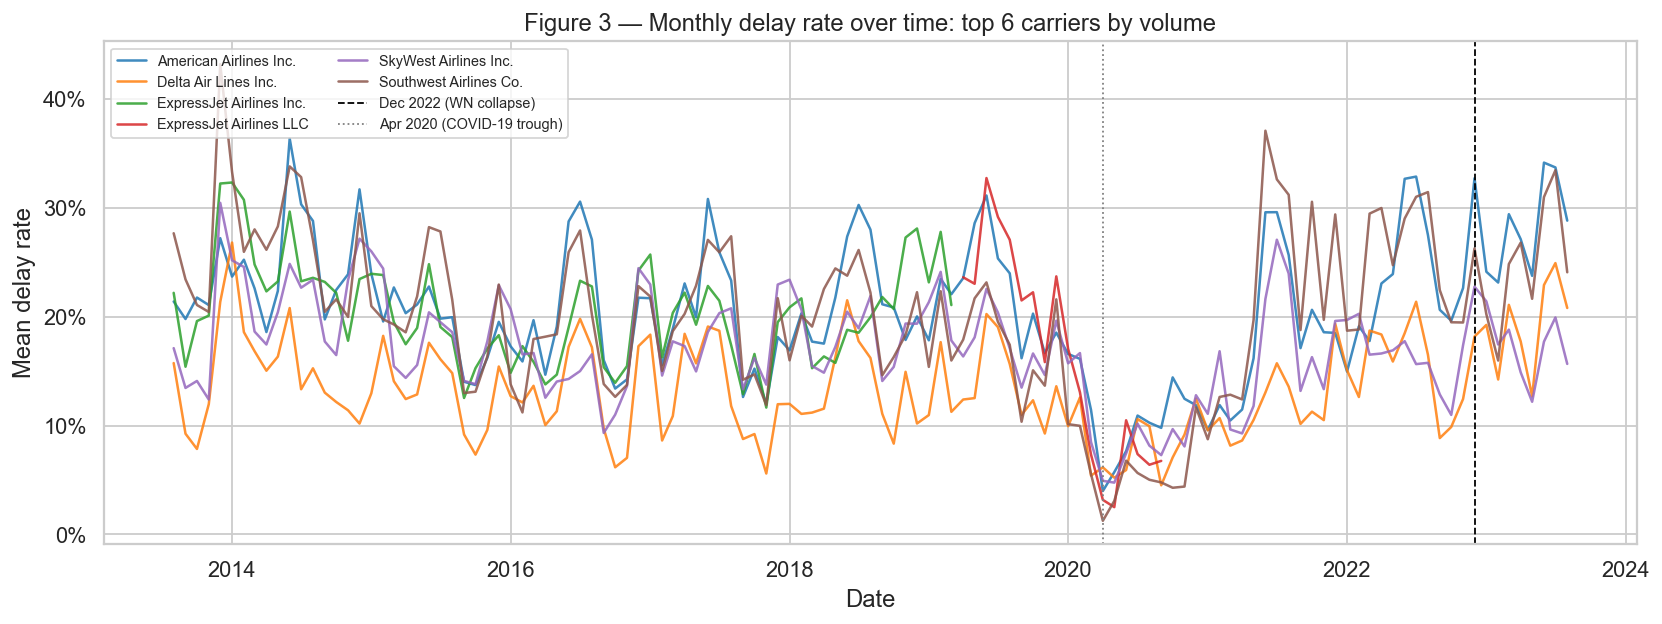

Saved: figures/fig3_carrier_timeline.png


In [11]:
# Select top 6 carriers by total flight volume
top6 = (df.groupby("carrier")["arr_flights"].sum()
          .nlargest(6).index.tolist())

df_top = df[df["carrier"].isin(top6)].copy()
df_top["date"] = pd.to_datetime(df_top[["year", "month"]].assign(day=1))

carrier_monthly = (
    df_top.groupby(["date", "carrier_name"])["delay_rate"]
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette("tab10", n_colors=6)

for (carrier, grp), color in zip(carrier_monthly.groupby("carrier_name"), palette):
    ax.plot(grp["date"], grp["delay_rate"],
            label=carrier, linewidth=1.4, color=color, alpha=0.85)

# Annotate Dec 2022 Southwest collapse
ax.axvline(pd.Timestamp("2022-12-01"), color="black",
           linestyle="--", linewidth=1, label="Dec 2022 (WN collapse)")
ax.axvline(pd.Timestamp("2020-04-01"), color="grey",
           linestyle=":", linewidth=1, label="Apr 2020 (COVID-19 trough)")

ax.set_xlabel("Date")
ax.set_ylabel("Mean delay rate")
ax.set_title("Figure 3 — Monthly delay rate over time: top 6 carriers by volume")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_carrier_timeline.png", dpi=150)
plt.show()
print("Saved: figures/fig3_carrier_timeline.png")

**Figure 3 interpretation:**  
This time-series view spans the full 2013–2023 range and reveals two key structural events. The COVID-19 trough (April 2020) shows a near-universal drop in delay rates — likely because dramatically reduced flight volume eliminated the cascade congestion that normally propagates delays. The December 2022 spike for Southwest (WN) is the most prominent single-carrier anomaly in the dataset, making it the primary validation target for the Isolation Forest: a well-calibrated anomaly detector should flag WN in December 2022 as the highest-scored outlier in the dataset. Persistent cross-carrier variation in delay rates also confirms that `carrier_code` is a meaningful predictor.

---
## 5. Export stats for `02_eda.md`

In [12]:
print("=== PASTE INTO 02_eda.md — Section 3 ===\n")
print(f"Dataset shape after filter: {df.shape}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print(f"Unique carriers: {df['carrier'].nunique()}")
print(f"Unique airports: {df['airport'].nunique()}")
print(f"High-delay threshold: {threshold:.4f}")
print(f"Positive class %: {df['high_delay'].mean()*100:.1f}%")
print()
print("Summary stats (key columns):")
print(stats[["Mean", "Std", "Min", "Median", "Max"]].to_string())

=== PASTE INTO 02_eda.md — Section 3 ===

Dataset shape after filter: (171426, 38)
Year range: 2013 – 2023
Unique carriers: 21
Unique airports: 391
High-delay threshold: 0.2415
Positive class %: 25.0%

Summary stats (key columns):
                          Mean       Std  Min    Median      Max
arr_flights           362.5285  992.8947  1.0  100.0000  21977.0
delay_rate              0.1834    0.1103  0.0    0.1707      1.0
cancel_rate             0.0248    0.0680  0.0    0.0049      1.0
divert_rate             0.0028    0.0124  0.0    0.0000      1.0
mean_delay_mins        11.4639   10.0466  0.0    9.5568    712.0
pct_carrier_ct          0.3706    0.2185  0.0    0.3488      1.0
pct_weather_ct          0.0435    0.0841  0.0    0.0104      1.0
pct_nas_ct              0.2534    0.1975  0.0    0.2317      1.0
pct_security_ct         0.0025    0.0186  0.0    0.0000      1.0
pct_late_aircraft_ct    0.2904    0.1916  0.0    0.2943      1.0
